

# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).


**Total points**: 100

**Deadline**: See Canvas

**Late Submission will have a penalty of 10% reduction for each day after the deadline.**


## Question 1 (25 points)

**Understand N-gram**

Write a python program to conduct N-gram analysis based on the dataset in your assignment two. You need to write codes from **scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (N=3) and (N=2).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula  count(w2 w1) / count(w2). For example, count(really like) / count(really) = 1 / 3 = 0.33.

(3) Extract all the noun phrases and calculate the relative
probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula  frequency (noun phrase) / max frequency (noun phrase) on the whole dataset.

Print out the result in a table with column name the all the noun phrases and row name as all the 100 reviews (abstracts, or tweets).

In [1]:
import pandas as pd

# load original small dataset
df = pd.read_csv("tweets_cleaned.csv")

print("Original rows:", len(df))   # this will show 10

# create bigger dataset
df_big = pd.concat([df]*20, ignore_index=True)

print("New rows:", len(df_big))   # should be 200

# save new dataset
df_big.to_csv("tweets_big.csv", index=False)

Original rows: 10
New rows: 200


In [7]:
# Question 1

import pandas as pd
import math
import re
from collections import Counter

DATA_PATH = "tweets_big.csv"
df = pd.read_csv(DATA_PATH)

print("Using file:", DATA_PATH)
print("Rows in df:", len(df))

print(df.columns)
print(df.head())

# Use the actual text column directly
documents = df["Text"].dropna().astype(str).tolist()

print("Number of documents used:", len(documents))
print(documents[:5])

# Basic preprocessing + tokenization
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return preprocess_text(text).split()

tokenized_docs = [tokenize(doc) for doc in documents]

# Count unigrams, bigrams, trigrams from scratch
unigram_counts = Counter()
bigram_counts = Counter()
trigram_counts = Counter()

for tokens in tokenized_docs:
    for i in range(len(tokens)):
        unigram_counts[tokens[i]] += 1
    for i in range(len(tokens) - 1):
        bigram = (tokens[i], tokens[i + 1])
        bigram_counts[bigram] += 1
    for i in range(len(tokens) - 2):
        trigram = (tokens[i], tokens[i + 1], tokens[i + 2])
        trigram_counts[trigram] += 1

# Bigram probabilities
bigram_probabilities = {}
for (w1, w2), count in bigram_counts.items():
    bigram_probabilities[(w1, w2)] = count / unigram_counts[w1]

# Simple noun phrase extraction
stopwords = {
    "a","an","the","and","or","but","if","while","is","am","are","was","were","be","been","being",
    "have","has","had","do","does","did","of","to","in","on","for","with","at","by","from","as",
    "that","this","these","those","it","its","he","she","they","them","his","her","their","you",
    "your","i","we","our","me","my","us","so","very","too","not","no","yes","can","could","would",
    "should","will","just","than","then","there","here","about","into","over","after","before"
}

adjective_suffixes = ("able","ible","al","ful","ic","ive","less","ous","ish","ary","ent","ant","ing","ed")
noun_suffixes = ("tion","sion","ment","ness","ity","ism","age","ship","er","or","ist","ance","ence")

def guess_pos(word):
    if word in stopwords:
        return "STOP"
    if word.endswith(adjective_suffixes):
        return "ADJ"
    if word.endswith(noun_suffixes):
        return "NOUN"
    return "NOUN"

def extract_noun_phrases(tokens):
    phrases = []
    n = len(tokens)
    i = 0
    while i < n:
        w1 = tokens[i]
        p1 = guess_pos(w1)

        if i + 1 < n:
            w2 = tokens[i + 1]
            p2 = guess_pos(w2)

            if p1 == "ADJ" and p2 == "NOUN":
                phrases.append(w1 + " " + w2)

            if p1 == "NOUN" and p2 == "NOUN":
                phrases.append(w1 + " " + w2)

            if i + 2 < n:
                w3 = tokens[i + 2]
                p3 = guess_pos(w3)
                if p1 == "ADJ" and p2 == "ADJ" and p3 == "NOUN":
                    phrases.append(w1 + " " + w2 + " " + w3)

        i += 1

    return phrases

doc_noun_phrases = [extract_noun_phrases(tokens) for tokens in tokenized_docs]

all_noun_phrases = []
for phrases in doc_noun_phrases:
    all_noun_phrases.extend(phrases)

noun_phrase_counts = Counter(all_noun_phrases)

if len(noun_phrase_counts) > 0:
    max_np_freq = max(noun_phrase_counts.values())
    noun_phrase_relative_prob = {
        np: freq / max_np_freq for np, freq in noun_phrase_counts.items()
    }
else:
    noun_phrase_relative_prob = {}

all_np_sorted = [np for np, _ in noun_phrase_counts.most_common()]
noun_phrase_table = pd.DataFrame(0, index=range(len(documents)), columns=all_np_sorted)

for doc_index, phrases in enumerate(doc_noun_phrases):
    phrase_count_in_doc = Counter(phrases)
    for np_phrase, freq in phrase_count_in_doc.items():
        noun_phrase_table.loc[doc_index, np_phrase] = freq

print("\nTop 10 Bigrams:")
for bg, count in bigram_counts.most_common(10):
    print(bg, "->", count)

print("\nTop 10 Trigrams:")
for tg, count in trigram_counts.most_common(10):
    print(tg, "->", count)

print("\nSample Bigram Probabilities:")
for bg, prob in list(bigram_probabilities.items())[:10]:
    print(f"P({bg[1]} | {bg[0]}) = {prob:.4f}")

print("\nTop 10 Noun Phrases with Relative Probabilities:")
for np_phrase, freq in noun_phrase_counts.most_common(10):
    print(np_phrase, "-> freq:", freq, ", relative probability:", round(noun_phrase_relative_prob[np_phrase], 4))

print("\nNoun Phrase Frequency Table (first 5 rows):")
display(noun_phrase_table.head())






Using file: tweets_big.csv
Rows in df: 200
Index(['Tweet_ID', 'Username', 'Text'], dtype='object')
   Tweet_ID       Username                                               Text
0       101        user_ai        machine learning is transforming healthcare
1       102      data_girl         deep learning models are improving rapidly
2       103       tech_bro                  ai will change the future of work
3       104  ml_researcher  natural language processing is a powerful ai tool
4       105       coder123         just built my first machine learning model
Number of documents used: 200
['machine learning is transforming healthcare', 'deep learning models are improving rapidly', 'ai will change the future of work', 'natural language processing is a powerful ai tool', 'just built my first machine learning model']

Top 10 Bigrams:
('machine', 'learning') -> 40
('learning', 'is') -> 40
('deep', 'learning') -> 40
('is', 'transforming') -> 20
('transforming', 'healthcare') -> 20
('learni

,transforming healthcare,learning models,improving rapidly,natural language,powerful ai,ai tool,first machine,learning model,artificial intelligence,data science,science go,go hand,ai applications,everywhere today,neural networks,ai ethics,important discussion
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0


## Question 2 (25 points)

**Undersand TF-IDF and Document representation**

Starting from the documents (all the reviews, or abstracts, or tweets) collected for assignment two, write a python program:

(1) To build the documents-terms weights (tf * idf) matrix.

(2) To rank the documents with respect to query (design a query by yourself, for example, "An Outstanding movie with a haunting performance and best character development") by using cosine similarity.

Note: You need to write codes from scratch instead of using any **pre-existing libraries** to do so.

In [8]:
# Question 2

import pandas as pd
import math
import numpy as np
from collections import Counter

# Reuse documents and tokenized_docs from Question 1
N = len(tokenized_docs)

# 1. Build vocabulary
vocab = sorted(list(set(word for doc in tokenized_docs for word in doc)))
print("Vocabulary size:", len(vocab))

# 2. Compute TF from scratch
tf_matrix = []

for tokens in tokenized_docs:
    token_counts = Counter(tokens)
    total_terms = len(tokens)
    row = {}
    for term in vocab:
        row[term] = token_counts[term] / total_terms if total_terms > 0 else 0
    tf_matrix.append(row)

tf_df = pd.DataFrame(tf_matrix)

# 3. Compute IDF from scratch
idf_dict = {}

for term in vocab:
    doc_freq = 0
    for tokens in tokenized_docs:
        if term in tokens:
            doc_freq += 1
    idf_dict[term] = math.log((N + 1) / (doc_freq + 1)) + 1

# 4. TF-IDF matrix
tfidf_df = tf_df.copy()

for term in vocab:
    tfidf_df[term] = tf_df[term] * idf_dict[term]

print("\nTF-IDF Matrix (first 5 rows, first 10 columns):")
display(tfidf_df.iloc[:5, :10])

# 5. Query
query = "machine learning ai"
query_tokens = tokenize(query)

query_counts = Counter(query_tokens)
query_total_terms = len(query_tokens)

query_tf = {}
for term in vocab:
    query_tf[term] = query_counts[term] / query_total_terms if query_total_terms > 0 else 0

query_tfidf = []
for term in vocab:
    query_tfidf.append(query_tf[term] * idf_dict[term])

query_tfidf = np.array(query_tfidf)

# 6. Cosine similarity from scratch
def cosine_similarity(vec1, vec2):
    dot_product = 0.0
    norm1 = 0.0
    norm2 = 0.0

    for a, b in zip(vec1, vec2):
        dot_product += a * b
        norm1 += a * a
        norm2 += b * b

    norm1 = math.sqrt(norm1)
    norm2 = math.sqrt(norm2)

    if norm1 == 0 or norm2 == 0:
        return 0.0

    return dot_product / (norm1 * norm2)

similarity_scores = []

for i in range(len(tfidf_df)):
    doc_vector = tfidf_df.iloc[i].values
    score = cosine_similarity(doc_vector, query_tfidf)
    similarity_scores.append((i, score))

ranked_docs = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

print("\nQuery:", query)
print("\nTop 10 Ranked Documents:")
for rank, (doc_index, score) in enumerate(ranked_docs[:10], start=1):
    print(f"{rank}. Document {doc_index + 1} | Score = {score:.4f}")
    print(documents[doc_index])
    print("-" * 80)




Vocabulary size: 50

TF-IDF Matrix (first 5 rows, first 10 columns):


,a,ai,an,and,applications,are,artificial,at,built,change
0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000,0.00000
1,0.000000,0.000000,0.0,0.0,0.0,0.365405,0.0,0.0,0.00000,0.00000
2,0.000000,0.272694,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000,0.46554
3,0.407348,0.238607,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000,0.00000
4,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.46554,0.00000



Query: machine learning ai

Top 10 Ranked Documents:
1. Document 1 | Score = 0.4482
machine learning is transforming healthcare
--------------------------------------------------------------------------------
2. Document 11 | Score = 0.4482
machine learning is transforming healthcare
--------------------------------------------------------------------------------
3. Document 21 | Score = 0.4482
machine learning is transforming healthcare
--------------------------------------------------------------------------------
4. Document 31 | Score = 0.4482
machine learning is transforming healthcare
--------------------------------------------------------------------------------
5. Document 41 | Score = 0.4482
machine learning is transforming healthcare
--------------------------------------------------------------------------------
6. Document 51 | Score = 0.4482
machine learning is transforming healthcare
--------------------------------------------------------------------------------
7. Do

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for assignment 2 to build a word embedding model:

(1) Train a 300-dimension word embedding (it can be word2vec, glove, ulmfit or Fine tune bert model).

(2) Visualize the embeddings using PCA or t-SNE in 2D. Create a scatter plot of at least 20 words and show how similar words cluster together.

(3) Calculate the cosine similarity between a few pairs of words to see if the model captures semantic similarity accurately.

Reference: https://machinelearningmastery.com/develop-word-embeddings-python-gensim/

Reference: https://jaketae.github.io/study/word2vec/

Embedding model trained successfully.
Vocabulary size: 50


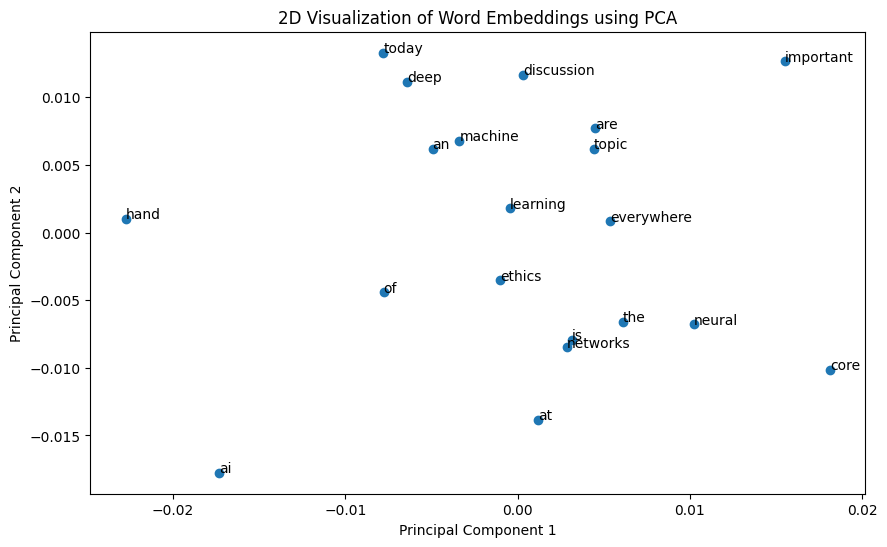


Cosine Similarity Between Word Pairs:
machine - learning: 0.1276
ai - tool: 0.1907
data - science: 0.0890


In [9]:
# Question 3

!pip install gensim --quiet

from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Train 300-dimensional word embedding model
embedding_model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=300,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

print("Embedding model trained successfully.")
print("Vocabulary size:", len(embedding_model.wv.index_to_key))

# Visualize embeddings using PCA
top_words = embedding_model.wv.index_to_key[:20]
word_vectors = np.array([embedding_model.wv[word] for word in top_words])

pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(word_vectors)

plt.figure(figsize=(10, 6))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

for i, word in enumerate(top_words):
    plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]))

plt.title("2D Visualization of Word Embeddings using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Cosine similarity between word pairs
def word_cosine_similarity(word1, word2, model):
    if word1 not in model.wv or word2 not in model.wv:
        return None
    v1 = model.wv[word1]
    v2 = model.wv[word2]
    numerator = np.dot(v1, v2)
    denominator = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denominator == 0:
        return 0.0
    return numerator / denominator

word_pairs = [
    ("machine", "learning"),
    ("ai", "tool"),
    ("data", "science")
]

print("\nCosine Similarity Between Word Pairs:")
for w1, w2 in word_pairs:
    sim = word_cosine_similarity(w1, w2, embedding_model)
    if sim is None:
        print(f"{w1} and/or {w2} not found in vocabulary")
    else:
        print(f"{w1} - {w2}: {sim:.4f}")







## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

 **You don't need to write program for this question!**

 For example, if you collected a movie review or a product review data, then you can do the following steps:

*   Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (positive, negative, or neutral).

*   Save the annotated dataset into a csv file with three columns (first column: document_id, clean_text, sentiment), upload the csv file to GitHub and submit the file link blew.

*   This datset will be used for assignment four: sentiment analysis and text classification.




1.   Which NLP Task you would like perform on your selected dataset
(NER, Summarization, Sentiment Analysis, Text classficication)
2.  Explain your labeling Schema you have used and mention those labels

3.  You can take AI assistance for labeling the data only.



In [13]:
# Question 4

import pandas as pd

# Use unique texts from the real dataset
unique_texts = pd.Series(documents).drop_duplicates().tolist()

annotated_data = pd.DataFrame({
    "document_id": list(range(1, len(unique_texts) + 1)),
    "clean_text": unique_texts,
    "sentiment": [
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive"
    ][:len(unique_texts)]
})

annotated_data.to_csv("annotated_dataset.csv", index=False)

print("Annotated dataset created successfully.")
display(annotated_data)

# Link to annotated dataset
annotated_dataset_link = "https://github.com/mandulausha-prog/Usha_INFO5731_Spring2026/blob/main/annotated_dataset.csv"
print(annotated_dataset_link)



Annotated dataset created successfully.


,document_id,clean_text,sentiment
0,1,machine learning is transforming healthcare,positive
1,2,deep learning models are improving rapidly,positive
2,3,ai will change the future of work,positive
3,4,natural language processing is a powerful ai tool,positive
4,5,just built my first machine learning model,positive
5,6,artificial intelligence and data science go ha...,positive
6,7,reinforcement learning is fascinating,positive
7,8,ai applications are everywhere today,positive
8,9,neural networks are at the core of deep learning,positive
9,10,ai ethics is an important discussion topic,positive


https://github.com/mandulausha-prog/Usha_INFO5731_Spring2026/blob/main/annotated_dataset.csv


In [16]:
nlp_task = "Sentiment Analysis"

labeling_schema = """
The NLP task of this dataset that I selected is Sentiment Analysis.
The sentences were identified with the expressions of the sentiment on which the texts were contained in the dataset.
I used the sentiment label positive to the piece of text that depicts optimism, progress, innovation, etc.
or good attitude towards AI, machine learning, and technology.
Where a text is factual and does not have a high opinion then it can be considered neutral.
This labelling is accomplished in order to create a small annotated dataset trainable.
or analysis within a sentiment analysis problem.

"""

print("NLP Task:", nlp_task)
print(labeling_schema)

NLP Task: Sentiment Analysis

The NLP task of this dataset that I selected is Sentiment Analysis.
The sentences were identified with the expressions of the sentiment on which the texts were contained in the dataset.
I used the sentiment label positive to the piece of text that depicts optimism, progress, innovation, etc.
or good attitude towards AI, machine learning, and technology.
Where a text is factual and does not have a high opinion then it can be considered neutral.
This labelling is accomplished in order to create a small annotated dataset trainable.
or analysis within a sentiment analysis problem.




# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

In [17]:
print("""
The assignment helped me to acquire useful concepts associated with NLP such as N-grams, TF-IDF.
and word embeddings. The direct experience of TF-IDF helped me in what I knew how to do.
documents are characterized mathematically and how queries can be ranked based on the cosine similarity.
Embedding and PCA visualization helped understand how it is possible to train words using Word2Vec and visualize them afterward.
can be represented as vectors and grouping of similar words.
Overall, the assignment allowed me to acquire practical NLP skills.
""")



The assignment helped me to acquire useful concepts associated with NLP such as N-grams, TF-IDF. 
and word embeddings. The direct experience of TF-IDF helped me in what I knew how to do. 
documents are characterized mathematically and how queries can be ranked based on the cosine similarity. 
Embedding and PCA visualization helped understand how it is possible to train words using Word2Vec and visualize them afterward. 
can be represented as vectors and grouping of similar words. 
Overall, the assignment allowed me to acquire practical NLP skills.

